# Исследование случайного леса на датасете Toyota Corolla
### исходники датасета --> [тута](https://www.kaggle.com/datasets/nameeerafatima/toyotacsv)

In [ ]:
import warnings;
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

## 1. Разделение выборки и подготовка данных

#### 1) Первичный анализ и очистка данных

Так как по условию задания предобработку данных нужно было взять из работы по линейной регрессии, я использовал тот же базовый подход, но немного упростил и сбатчил его для удобства чтения. Основные задачи здесь остались теми же: обработка пропусков, исправление смешанных категориальных и числовых значений, а также очистка некорректных символов и битых значений.

In [131]:
df = pd.read_csv('./Toyota.csv')

print(f"размер датасета --> {df.shape}")

df = df.drop(columns="Unnamed: 0")
df.head()

размер датасета --> (1436, 11)


,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23.0,46986,Diesel,90,1.0,0,2000,three,1165
1,13750,23.0,72937,Diesel,90,1.0,0,2000,3,1165
2,13950,24.0,41711,Diesel,90,NaN,0,2000,3,1165
3,14950,26.0,48000,Diesel,90,0.0,0,2000,3,1165
4,13750,30.0,38500,Diesel,90,0.0,0,2000,3,1170


In [132]:
print(f"\nПропуски : \n {df.isnull().sum()}")


Пропуски : 
 Price          0
Age          100
KM             0
FuelType     100
HP             0
MetColor     150
Automatic      0
CC             0
Doors          0
Weight         0
dtype: int64


In [133]:
#проверяем категориальные колонки на mixed values
obj_cols = df.select_dtypes(include='object').columns

# ищем число конвертируемых в число к общему числу и сами поломанные значения
for col in obj_cols:
    print("\n",col)
    converted = pd.to_numeric(df[col],errors="coerce")
    total = df[col].notna().sum()
    ok = converted.notna().sum()
    print(f"соотношение конвертируемых в число к общему числу --> {ok}/{total}")
    print("\n Не валидные значения :")
    
    bad_mask = converted.isna() & df[col].notna()
    bad_value = df.loc[bad_mask,col]
    
    print(col)
    print(bad_value)


 KM
соотношение конвертируемых в число к общему числу --> 1421/1436

 Не валидные значения :
KM
6       ??
64      ??
91      ??
112     ??
125     ??
131     ??
398     ??
491     ??
1049    ??
1120    ??
1421    ??
1425    ??
1428    ??
1432    ??
1434    ??
Name: KM, dtype: str

 FuelType
соотношение конвертируемых в число к общему числу --> 0/1336

 Не валидные значения :
FuelType
0       Diesel
1       Diesel
2       Diesel
3       Diesel
4       Diesel
         ...  
1430    Petrol
1431    Petrol
1432    Petrol
1433    Petrol
1435    Petrol
Name: FuelType, Length: 1336, dtype: str

 HP
соотношение конвертируемых в число к общему числу --> 1430/1436

 Не валидные значения :
HP
6       ????
9       ????
15      ????
631     ????
638     ????
1245    ????
Name: HP, dtype: str

 Doors
соотношение конвертируемых в число к общему числу --> 1433/1436

 Не валидные значения :
Doors
0      three
167     four
324     five
Name: Doors, dtype: str


По коду выше видно, что колонки с типом string в основном были строкой из-за некоторых битых токенов, колонка FuelType как категориальная ок, после того как были определены поломанные значения их можно заменить на опр значения

In [134]:
# чистим пробелы
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

df = df.replace({
    "nan": np.nan,
    "None": np.nan,
    "": np.nan,
    "??": np.nan,
    "????": np.nan
})

# фиксим Doors
df["Doors"] = df["Doors"].replace({
    "three": 3,
    "four": 4,
    "five": 5,
    "3": 3,
    "4": 4,
    "5": 5
})

# приводим нужные колонки к numeric
numeric_cols = ["Price", "Age", "KM", "HP", "MetColor", "Automatic", "CC", "Doors", "Weight"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)
print(df.isnull().sum())

Price          int64
Age          float64
KM           float64
FuelType         str
HP           float64
MetColor     float64
Automatic      int64
CC             int64
Doors          int64
Weight         int64
dtype: object
Price          0
Age          100
KM            15
FuelType     100
HP             6
MetColor     150
Automatic      0
CC             0
Doors          0
Weight         0
dtype: int64


#### 2) EDA


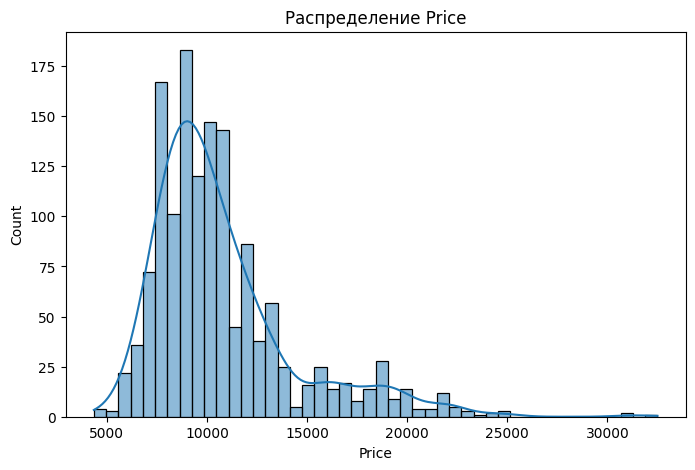

In [135]:
#гисторама + kde для прайса
plt.figure(figsize=(8, 5))
sns.histplot(df["Price"], kde=True)
plt.title("Распределение Price")
plt.show()

Гистограмма и KDE показали, что основная часть машин находится в ценовом диапазоне около 10К

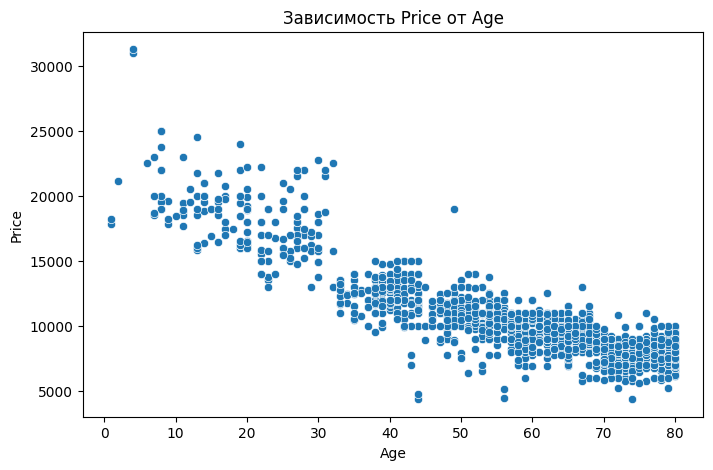

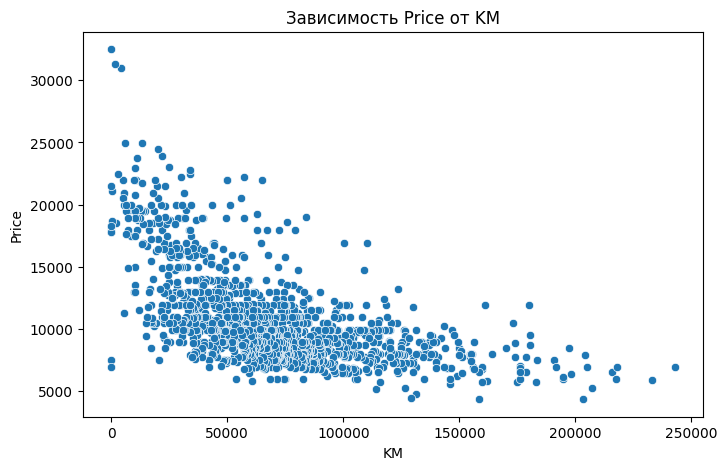

In [136]:
#scatterplots под основные категории
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="Price")
plt.title("Зависимость Price от Age")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="KM", y="Price")
plt.title("Зависимость Price от KM")
plt.show()

Scatterplots явно отражают суть того, что при их увелечении значение прайса падает 

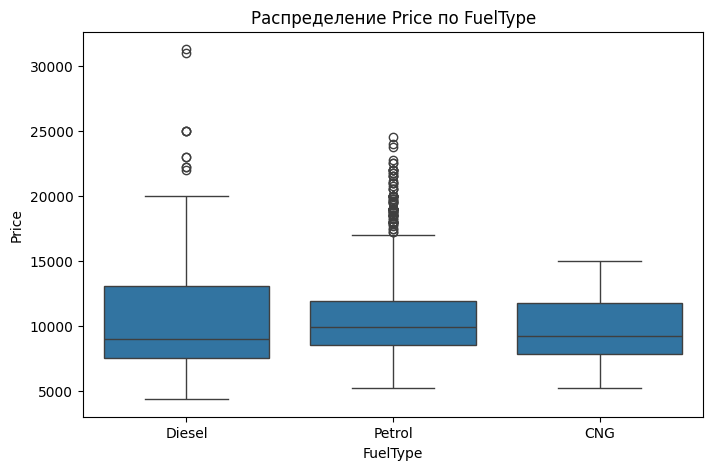

In [137]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="FuelType", y="Price")
plt.title("Распределение Price по FuelType")
plt.show()

Boxplots выше показывают, что бензиновых автомобилей на датасете преобладающее количество

#### 3) Feature engineering

In [138]:
df["KM_per_Age"] = df["KM"] / df["Age"]
df["KM_per_Age"] = df["KM_per_Age"].replace([np.inf, -np.inf], np.nan)

#One-Hot encoding
df = pd.get_dummies(df, columns=["FuelType"],drop_first=True) 
df.head()

,Price,Age,KM,HP,MetColor,Automatic,CC,Doors,Weight,KM_per_Age,FuelType_Diesel,FuelType_Petrol
0,13500,23.0,46986.0,90.0,1.0,0,2000,3,1165,2042.869565,True,False
1,13750,23.0,72937.0,90.0,1.0,0,2000,3,1165,3171.173913,True,False
2,13950,24.0,41711.0,90.0,NaN,0,2000,3,1165,1737.958333,True,False
3,14950,26.0,48000.0,90.0,0.0,0,2000,3,1165,1846.153846,True,False
4,13750,30.0,38500.0,90.0,0.0,0,2000,3,1170,1283.333333,True,False


Вывод по блоку:

1) Для FuelType был сделан one-hot encoding, так как там ток 3 категориальнх значения

2) Ввел фичу пробега KM_per_Age

#### 4) Разделение выборки

In [139]:
X = df.drop(columns=["Price"])
y = df["Price"]

In [140]:
# разделение датасета на обучающую и тестовую выборку
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1148, 11)
X_test: (288, 11)
y_train: (1148,)
y_test: (288,)


Разделил выборку на train/test, на трейне дальше будут подбираться гиперпараметры при помощи кросс-валидации

Вопросы к 1 блоку :)

1) Сделали ли вы предобработку данных для случайного леса? Отличалась ли она от предобработки данных для линейной модели? Если до, то почему?
2) Как именно вы разделили выборку? 
3) На сколько частей нужно делить выборку при использовании кросс-валидации?
4) Можно ли не использовать кросс-валидацию? Если да, то как делить выборку в таком случае? 


Ответы:
1) Предабробатка была таже, что и на линейной регресии, только без приведения признаков к общему масштабу, для деревьев это роли не играет
2) Выборка была разделена на train/test(80/20), на первом будут обучаться деревья и через кросс-валидацию подбираться гиперпараметры, последний же идет финальным чеккингом
3) Для кросс-валидации разбивается на k фолдов, оно выбирается самостоятельно, но лично я буду использовать 5 фолдов
6) Конечно можно) Тогда надо разбить текущий датасет помимо трейна и теста еще и на validation выборку, уже на нем будет идти подбор гиперпараметров, в таком случае можно сплитить в отношении (60/20/20)

## 2. Обучение моделей

Я разбил блок на два сплита, первый в котором подбираю гипперпараметры руками и второй, где подбор через кросс-валидацию

### 1) Ручной подбор параметров

In [141]:
# количество признаков в выборке, будет дальше исплоьзоваться для ограничения выбора в случайном лесе
# каждое дерево будет выбирать n/3 признаков из того, что было ей предоставлено
n_features = X_train.shape[1]

#случайный лес
RFmodel = RandomForestRegressor(n_estimators=100,max_depth=10,random_state=42,n_jobs=-1,max_features=int(n_features/3))

# фиттим данные(то на чем будут учиться деревья)
RFmodel.fit(X_train,y_train)

# тест на train выборке
RF_train_score = RFmodel.score(X_train,y_train)
# тест на test выборке
RF_test_score = RFmodel.score(X_test,y_test)

print("Коэффицент детерминации : ")
print(f"Скорринг случайного леса на трейне --> {RF_train_score}")
print(f"Скорринг случайного леса на тесте --> {RF_test_score}")

Коэффицент детерминации : 
Скорринг случайного леса на трейне --> 0.9592975488487528
Скорринг случайного леса на тесте --> 0.9029547284029903


In [142]:
# одиночное дерево решений
DTmodel = DecisionTreeRegressor(max_depth=10,random_state=42)
# фиттим данные(то на чем будет учиться дерево)
DTmodel = DTmodel.fit(X_train,y_train)

# тест на train выборке
DT_train_score = DTmodel.score(X_train,y_train)
# тест на test выборке
DT_test_score = DTmodel.score(X_test,y_test)

print("Коэффицент детерминации : ")
print(f"Скорринг дерева решений на трейне --> {DT_train_score}")
print(f"Скорринг дерева решений на тесте --> {DT_test_score}")

Коэффицент детерминации : 
Скорринг дерева решений на трейне --> 0.9563628935404604
Скорринг дерева решений на тесте --> 0.8380591761730691


**Вопросы для анализа:**
1) Сравнение скорости: сравните, какая модель обучалась быстрее. 
2) Можно ли добиться одинаковой или близкой к одинаковой скорости?
3) Сравнение качества: сравните результаты одного дерева и случайного леса. 


**Ответы:**
1) Безусловно быстрее обучалось одиночное дерево решений, так как оно одно. Лес в свою очередь имеет таких же 100 деревьев поэтому его обучение занимает время
2) Можно, так как в лесе деревья строятся независимо друг от друга, то можно распараллелить построения деревьев на свободные вычислительные рессурсы(ядра), при создании леса указывается n_jobs=-1
3) Для леса кэф детерминации выше чем для одиночного дерева решений. Про дерево решений можно сказать, что на текущей глубине оно явно переобучилось, видно по расхождению скоринга на трейне и тесте

**Личные наблюдения**
1) n_jobs=-1 явно ускорило построение случайного леса, хоть и датасет небольшой, но по времени на десятые прирост есть
2) Случайный лес стал выдавать более лучшие показатели на тесте после того, как ввел ограничения на выбор признаков для каждого дерева через max_features=int(n_features/3). Деревья меньше выбирают сильные признаки и получаются более случайные деревья, которые по итогу лучше снижают общую диссперсию. До было --> 0.8870, ПОСЛЕ --> 0.9029, видно, что прирост существенный

### 2) Подбор гипперпараметров через кросс-валидацию

In [ ]:
# подбор гиперпараметров через кросс-валидацию

#сетка параметров
rf_params = {
    'n_estimators': [50,100,200],
    'max_depth' : [5,10,15,None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4],
    'max_features' : ["sqrt","log2",None]
}

#случайный лес под кросс-валидацию
RFmodel_cv = RandomForestRegressor(random_state=42,n_jobs=-1)

rf_grid = GridSearchCV(estimator=RFmodel_cv,
                       param_grid=rf_params,
                       cv=5,
                       scoring="neg_root_mean_squared_error",
                       n_jobs=-1)

# фиттим данные(то на чем будут учиться деревья)
rf_grid.fit(X_train,y_train)

print(f"Лучшие параметры для леса : {rf_grid.best_params_}")
print("Лучший CV RMSE:", -rf_grid.best_score_)

Лучшие параметры для леса : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Лучший CV RMSE: 1282.6111764351976


In [ ]:
# случайный лес с лучшими подобранными гипперпараметрами
best_rf = rf_grid.best_estimator_

rf_train_pred = best_rf.predict(X_train)
rf_test_pred = best_rf.predict(X_test)

print("R2(коэффицент детерминации) :")
print(f"Случайный лес на трейне --> {r2_score(y_train,rf_train_pred)}")
print(f"Случайный лес на тесте --> {r2_score(y_test,rf_test_pred)}")

print("RMSE : ")
print(f"Случайный лес на тесте --> {root_mean_squared_error(y_test,rf_test_pred)}")

print("MAE :")
print(f"Случайный лес на тесте --> {mean_absolute_error(y_test,rf_test_pred)}")

R2(коэффицент детерминации) :
Случайный лес на трейне --> 0.965400597606043
Случайный лес на тесте --> 0.89507032796717
RMSE : 
Случайный лес на тесте --> 1183.2389688363587
MAE :
Случайный лес на тесте --> 846.5085663589882


In [ ]:
# лучшая глубина из кросс-валидации
best_depth = rf_grid.best_params_['max_depth']

# одиночное дерево решений
dt_model = DecisionTreeRegressor(max_depth=best_depth,random_state=42)

dt_model.fit(X_train,y_train)

dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

print("R2(коэффицент детерминации) :")
print(f"Дерево решений на трейне --> {r2_score(y_train, dt_train_pred)}")
print(f"Дерево решений на тесте --> {r2_score(y_test,dt_test_pred)}")

print("RMSE : ")
print(f"Дерево решений на тесте --> {root_mean_squared_error(y_test,dt_test_pred)}")

print("MAE :")
print(f"Дерево решений на тесте --> {mean_absolute_error(y_test,dt_test_pred)}")

R2(коэффицент детерминации) :
Дерево решений на трейне --> 1.0
Дерево решений на тесте --> 0.7407721286369097
RMSE : 
Дерево решений на тесте --> 1859.7910500913806
MAE :
Дерево решений на тесте --> 1139.173611111111


**Небольшие выводы по блоку**
1) Если проводить такой же анализ, который был проведен на ручном этапе подбора параметров, то выводы будут аналогичны
2) Так как в текущем случае одиночное дерево решений не было ограничено по глубине, то оно переобучилось) очень заметно по кэфу детерминации

**Дальше будут за основу браться значения с кросс-валидации**
1) Случайный лес через CV --> best_rf
2) Одиночное дерево решений --> dt_model

## 3. Оценка качества и сравнение моделей

In [152]:
rows = [
    {
        "Model": "Ridge (hw04)",
        "Test R2": 0.8173367098997621,
        "Test RMSE": 1561.1654970896946,
        "Test MAE": 1029.6205936871588,
    }
]

dt_test_pred = dt_model.predict(X_test)
rows.append({
    "Model": "DecisionTreeRegressor",
    "Test R2": r2_score(y_test, dt_test_pred),
    "Test RMSE": root_mean_squared_error(y_test, dt_test_pred),
    "Test MAE": mean_absolute_error(y_test, dt_test_pred),
})

rf_test_pred = best_rf.predict(X_test)
rows.append({
    "Model": "RandomForestRegressor",
    "Test R2": r2_score(y_test, rf_test_pred),
    "Test RMSE": root_mean_squared_error(y_test, rf_test_pred),
    "Test MAE": mean_absolute_error(y_test, rf_test_pred),
})

df_compare = pd.DataFrame(rows).round(4)
df_compare.sort_values(by="Test R2", ascending=False)


,Model,Test R2,Test RMSE,Test MAE
2,RandomForestRegressor,0.8951,1183.2390,846.5086
0,Ridge (hw04),0.8173,1561.1655,1029.6206
1,DecisionTreeRegressor,0.7408,1859.7911,1139.1736


**Выводы по блоку :**

1) По таблице видно, что по всем метрикам лучший результат у случайного леса, он более устойчив к переобучению и шуму чем одиночное дерево решений, а также видит зависимости которые линейная регрессия не уловила
2) Полученные результаты можно считать хорошими для данной задачи. Линейная модель уже давала адекватное качество, но случайный лес улучшил итоговые метрики и лучше справился с предсказанием цены автомобилей. Это означает, что выбранные признаки действительно содержат полезную информацию, а сама задача хорошо решается не только линейным подходом, но и более гибкой моделью на основе деревьев.